#4 - Preparing GTA as Ground Truth: Tariff-Label Construction


This notebook turns the Global Trade Alert (GTA) extract into the project's prediction labels
and joins them to the GDELT feature matrix, producing the model-ready dataset. It (i) defines the
positive tariff event, (ii) fixes the label event time, (iii) assigns each tariff to corridor(s),
(iv) constructs leakage-safe forward-looking labels at the 30/60/90-day horizons, and (v) merges
them onto gdelt_features_monthly.parquet.



In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,
    "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,"figure.autolayout":True})
ACCENT="#1F3864"; ORANGE="#C55A11"; RED="#B22222"; TEAL="#2E7D6F"
DATA=Path("data"); FIG=Path("eda_figures"); FIG.mkdir(exist_ok=True)
gta=pd.read_csv(DATA/"gta_interventions_2107.csv", dtype=str)
feat=pd.read_parquet(DATA/"gdelt_features_monthly.parquet")
for c in ['Date Announced','Date Implemented','Date Removed']:
    gta[c+'_dt']=pd.to_datetime(gta[c],errors='coerce')
print("GTA:",gta.shape,"| feature matrix:",feat.shape,"| corridors:",feat.index.get_level_values('pair_str').nunique())

GTA: (1605, 22) | feature matrix: (3088, 25) | corridors: 23


In [ ]:
# Same two-tier corridor set and HS target headings as the feature pipeline
TIER1=[("EUR","USA"),("EUR","CHN"),("USA","CHN"),("USA","CAN"),("EUR","BRA"),("USA","BRA"),
 ("EUR","MEX"),("USA","MEX"),("EUR","IND"),("USA","IND"),("CHN","IND"),("CHN","BRA"),
 ("EUR","KOR"),("USA","KOR"),("EUR","JPN"),("CHN","JPN"),("CHN","KOR")]
TIER2=[("USA","JPN"),("CHN","CAN"),("EUR","CAN"),("CHN","MEX"),("JPN","KOR"),("IND","BRA")]
PAIRS_T1={frozenset(p) for p in TIER1}; PAIRS_T2={frozenset(p) for p in TIER2}
PAIRS_ALL=PAIRS_T1|PAIRS_T2
TARGET_HS={"2102","2106","3002","3502","3504","3507"}
EU={"Austria","Belgium","Bulgaria","Croatia","Cyprus","Czechia","Denmark","Estonia","Finland",
 "France","Germany","Greece","Hungary","Ireland","Italy","Latvia","Lithuania","Luxembourg","Malta",
 "Netherlands","Poland","Portugal","Romania","Slovakia","Slovenia","Spain","Sweden"}
NAME2ENT={"United States of America":"USA","China":"CHN","Canada":"CAN","Brazil":"BRA","Mexico":"MEX",
 "India":"IND","Republic of Korea":"KOR","Japan":"JPN"}
def to_ent(name):
    name=name.strip(); return "EUR" if name in EU else NAME2ENT.get(name)
def entset(cell):
    if pd.isna(cell): return set()
    return {e for e in (to_ent(x) for x in str(cell).split(",")) if e}
def hs_headings(cell):
    if pd.isna(cell): return set()
    return {tok.strip()[:4] for tok in str(cell).split(",") if tok.strip()[:4].isdigit()}
print("Corridor pairs:",len(PAIRS_ALL),"| HS headings:",TARGET_HS)

Corridor pairs: 23 | HS headings: {'3002', '3504', '2106', '2102', '3507', '3502'}


The prediction target is the occurrence of a harmful tariff measure on a corridor. Following
the GTA EDA (which found only 228 tariff interventions, 14.2% of the extract) and the target-variable
analysis (a >=5% magnitude target is not constructible because GTA records no rate), the positive
event is defined by three criteria, applied as a funnel.

In [ ]:
#Definition of the positive event
is_tariff=(gta['Intervention Type'].str.contains("tariff",case=False,na=False)
           & ~gta['Intervention Type'].str.contains("non-tariff",case=False,na=False))
is_red=gta['GTA Evaluation'].eq("Red")
gta['hs']=gta['Affected Products'].apply(hs_headings)
hits_hs=gta['hs'].apply(lambda s: bool(s & TARGET_HS))
funnel=pd.DataFrame({
 "criterion":["All interventions","Tariff type (import tariff / quota)","  AND harmful (Red)","  AND touches target HS heading"],
 "n":[len(gta),int(is_tariff.sum()),int((is_tariff&is_red).sum()),int((is_tariff&is_red&hits_hs).sum())]})
print(funnel.to_string(index=False))
print("\nTariff-type breakdown:"); print(gta.loc[is_tariff,'Intervention Type'].value_counts().to_string())
POS = is_tariff & is_red & hits_hs
gta_pos=gta[POS].copy()
print("\nPositive tariff events (pre-corridor mapping):", len(gta_pos))

                          criterion    n
                  All interventions 1605
Tariff type (import tariff / quota)  228
                  AND harmful (Red)   92
      AND touches target HS heading   92

Tariff-type breakdown:
Intervention Type
Import tariff          176
Import tariff quota     52

Positive tariff events (pre-corridor mapping): 92


In [4]:
gta_pos=gta_pos.dropna(subset=['Date Announced_dt'])
print("Positive events with an announcement date:", len(gta_pos),
      "| range:", gta_pos['Date Announced_dt'].min().date(),"->",gta_pos['Date Announced_dt'].max().date())
lag=(gta_pos['Date Implemented_dt']-gta_pos['Date Announced_dt']).dt.days
print("Announce->implement lag among positives: median %.0f, mean %.0f, share with lag>0: %.0f%%"%(
      lag.median(), lag.mean(), 100*(lag>0).mean()))

Positive events with an announcement date: 92 | range: 2015-10-26 -> 2026-02-20
Announce->implement lag among positives: median 7, mean 70, share with lag>0: 85%


In [5]:
rows=[]
for _,rw in gta_pos.iterrows():
    ies=entset(rw['Implementing Jurisdictions']); aes=entset(rw['Affected Jurisdictions'])
    for ie in ies:
        for ae in aes:
            if ie==ae: continue
            pr=frozenset({ie,ae})
            if pr in PAIRS_ALL:
                rows.append({"pair_str":"-".join(sorted({ie,ae})),"date":rw['Date Announced_dt'],
                             "tier":"T1" if pr in PAIRS_T1 else "T2","gta_id":rw['Intervention ID']})
ev_lab=pd.DataFrame(rows).drop_duplicates(['pair_str','date','gta_id'])
print("Corridor-mapped positive tariff events:", len(ev_lab),
      "| distinct interventions:", ev_lab['gta_id'].nunique(),
      "| corridors with >=1 event:", ev_lab['pair_str'].nunique())
print("\nEvents per corridor (top 12):"); print(ev_lab['pair_str'].value_counts().head(12).to_string())

Corridor-mapped positive tariff events: 260 | distinct interventions: 92 | corridors with >=1 event: 23

Events per corridor (top 12):
pair_str
CHN-USA    36
EUR-USA    24
BRA-USA    24
IND-USA    23
MEX-USA    16
KOR-USA    16
JPN-USA    15
CAN-USA    14
BRA-EUR    12
BRA-IND    11
EUR-IND    10
BRA-CHN    10


Leakage-safe forward-looking labels (30/60/90 days)

For each corridor-month in the feature matrix, the label at horizon h is 1 if a qualifying tariff
was implemented in the h days after the end of that month. Features summarise information up to
the month end; the label window opens strictly afterwards, so no future information enters the
features (Kaufman et al., 2012; Bergmeir & Benitez, 2012).

In [6]:
from pandas.tseries.offsets import MonthEnd
idx=feat.index.to_frame(index=False)  # pair_str, month
idx['origin']=pd.to_datetime(idx['month'])+MonthEnd(0)   # last day of the feature month
# per-corridor sorted ANNOUNCEMENT dates for fast forward-window counting
ev_by_pair={p:np.sort(g['date'].values) for p,g in ev_lab.groupby('pair_str')}
def label_for(pair,origin,h):
    arr=ev_by_pair.get(pair);
    if arr is None: return 0
    lo=np.searchsorted(arr, np.datetime64(origin),'right')
    hi=np.searchsorted(arr, np.datetime64(origin+pd.Timedelta(days=h)),'right')
    return int(hi>lo)
for h in [30,60,90]:
    idx[f'y_{h}d']=[label_for(p,o,h) for p,o in zip(idx['pair_str'],idx['origin'])]
lab=idx.set_index(['pair_str','month'])[['y_30d','y_60d','y_90d']]
data=feat.join(lab)
print("Positive rates (all 23 corridors / training scope):")
for h in [30,60,90]:
    y=data[f'y_{h}d']; print(f"  y_{h}d: positives={int(y.sum()):4d}  rate={100*y.mean():.2f}%")
print("\nPositive rates (Tier-1 evaluation scope only):")
t1=data[data['tier']=='T1']
for h in [30,60,90]:
    y=t1[f'y_{h}d']; print(f"  y_{h}d: positives={int(y.sum()):4d}  rate={100*y.mean():.2f}%")

Positive rates (all 23 corridors / training scope):
  y_30d: positives= 182  rate=5.89%
  y_60d: positives= 345  rate=11.17%
  y_90d: positives= 479  rate=15.51%

Positive rates (Tier-1 evaluation scope only):
  y_30d: positives= 157  rate=6.70%
  y_60d: positives= 297  rate=12.68%
  y_90d: positives= 409  rate=17.46%


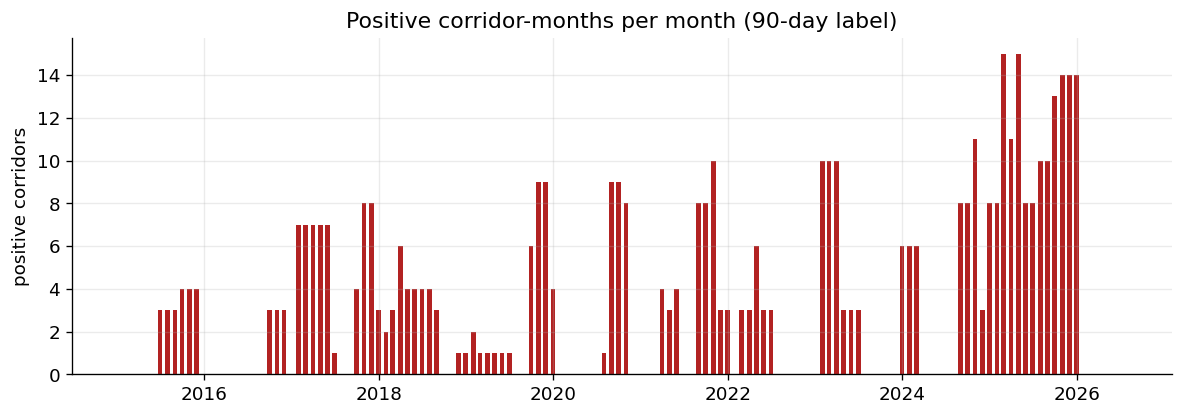

Imbalance ratio (neg:pos), Tier-1, by horizon:
  y_30d: 2186:157  (~14:1)
  y_60d: 2046:297  (~7:1)
  y_90d: 1934:409  (~5:1)


In [7]:
# temporal distribution of positive labels + imbalance summary
fig,ax=plt.subplots(figsize=(10,3.6))
m=data.reset_index(); m['month']=pd.to_datetime(m['month'])
s=m.groupby('month')['y_90d'].sum()
ax.bar(s.index,s.values,width=20,color=RED); ax.set_title("Positive corridor-months per month (90-day label)")
ax.set_ylabel("positive corridors"); plt.savefig(FIG/"labels_temporal.png",bbox_inches='tight'); plt.show()
print("Imbalance ratio (neg:pos), Tier-1, by horizon:")
for h in [30,60,90]:
    y=t1[f'y_{h}d']; pos=int(y.sum()); neg=len(y)-pos
    print(f"  y_{h}d: {neg}:{pos}  (~{neg/max(pos,1):.0f}:1)")

In [8]:
# final modelling dataset = features + 3 horizon labels + tier + keys
data.to_parquet(DATA/"modelling_dataset.parquet")
print("saved -> data/modelling_dataset.parquet | shape:", data.shape)
print("columns:", [c for c in data.columns if c.startswith('y_') or c=='tier'][:6], "... + 17 features")
data[['tier','y_30d','y_60d','y_90d']].head(8)

saved -> data/modelling_dataset.parquet | shape: (3088, 28)
columns: ['tier', 'y_30d', 'y_60d', 'y_90d'] ... + 17 features


tier  y_30d  y_60d  y_90d
pair_str month                               
BRA-CHN  2015-02-01   T1      0      0      0
         2015-03-01   T1      0      0      0
         2015-04-01   T1      0      0      0
         2015-05-01   T1      0      0      0
         2015-06-01   T1      0      0      0
         2015-07-01   T1      0      0      0
         2015-08-01   T1      0      0      0
         2015-09-01   T1      0      0      0